<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Evaluating Player Impact in the NBA: Regression Based Stat Attribution to Plus Minus**

Estimated time needed: **20** minutes

## Overview

In this lab, you will explore how data science and **machine learning** can be applied to understand a basketball player's impact on the game. Using NBA data from the 2024–2025 season, you’ll investigate how a variety of in-game stats relate to a player's overall contribution, measured through the **plus-minus score**. You will walk through core concepts like **data preprocessing**, **feature engineering**, **correlation analysis**, and **regression modeling**—including both **tree-based models** and **regularized linear regression**. Along the way, you’ll learn how to interpret model outputs, handle challenges like **overlapping or redundant features**, and extract meaningful insights from **statistical patterns** in performance data. Your goal will be to bridge the gap between raw sports data and actionable insights about player value using practical tools from data science.

For this lab, you’ll be modeling none other than **Shai Gilgeous-Alexander**, the reigning **NBA champion**, **league MVP**, and **Finals MVP**. The Canadian superstar recently signed a historic **four-year, \$285 million supermax extension** with the Oklahoma City Thunder. This makes him the **highest-paid player in NBA history** with an annual salary of \$71 million. On the surface, the accolades and contract seem to justify the price, but does the data back it up?

In this lab, you’ll dig into Shai’s game stats from the 2024–2025 season to uncover how his performance translates into on-court impact, and evaluate whether the numbers truly reflect his value to the team. By participating in this lab, you’ll develop a strong intuition for how to transform messy, real world data into actionable insights using regression and statistical reasoning. You'll learn to identify which features matter most, manage overlapping variables, and interpret model outcomes with clarity. This experience will strengthen your ability to extract meaningful patterns from data, an essential skill for any aspiring data scientist—while building your confidence to tackle open-ended, analytical problems in any domain.

<img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/FE6Inx7iBQCATyoZPeK1_Q/shai.jpg" width="60%" alt="shai">


### Regression

**Regression** is a foundational statistical technique that you will use to model and analyze the relationship between a **dependent variable** and one or more **independent variables**. In this lab, regression will help you understand how different aspects of a player’s performance, such as **shooting accuracy**, **assists**, or **defensive plays**, contribute to their overall impact on the game, as reflected by the **plus-minus score**. By fitting models that predict plus-minus from these features, you’ll identify which stats are most influential and how they interact. This will allow you to uncover patterns in player performance and use data to evaluate a player's value beyond just traditional scoring metrics.

### Plus-Minus Score

The **plus-minus** score is a score that represents the point differential between teams while a certain player is on the court. This general metric captures many asepcts of a players game that contributes to the point differential of the game. It's effective for vague player quality but fails to isolate specific impacts. Using regression and real game data, we'll deduce the major aspects of Shai's contribution to the team.

### Variation
Throughout the lab, you may find the guided text deviating from what's actually happening with your work. This variation is due to several inherent characteristics of the data and modeling process:

- **Random Sampling Effects**
    - Train-test splits are randomized, meaning different students will have different subsets of games for training and testing
    - Random Forest bootstrapping creates different decision trees each time the model runs
    - Cross-validation folds may partition the data differently, leading to varying hyperparameter selections
- **Small Dataset Limitations**
    - With limited games per season (~82 regular season + playoffs), small changes in the training set can significantly impact model behavior
    - High variance in basketball performance means individual games can heavily influence overall patterns
    - Outlier games (exceptional performances or off-nights) may disproportionately affect your specific data split
- **Model Sensitivity**
    - Hyperparameter optimization may converge to different local optima depending on your data split
    - Feature importance rankings can shift when models are trained on slightly different datasets
    - Correlation values may vary based on which games are included in your analysis


## __Table of Contents__

<ol>
    <li><a href="#Overview">Overview</a></li>
    <li><a href="#Objectives">Objectives</a></li>
    <li>
        <a href="#Setup">Setup</a>
        <ol>
            <li><a href="#Installing-required-libraries">Installing required libraries</a></li>
            <li><a href="#Importing-required-libraries">Importing required libraries</a></li>
            <li><a href="#Display-Some-Player-Stats">Display Some Player Stats</a></li>
        </ol>
    </li>
    <li>
        <a href="#Loading-the-Dataset">Loading the Dataset</a>
    </li>
     <li>
        <a href="#Preparing-the-Data">Preparing the Data</a>
        <ol>
            <li><a href="#Getting-Game-Data">Getting Game Data</a></li>
            <li><a href="#Feature-Engineering">Feature Engineering</a></li>
            <li><a href="#Isolating-Relevant-Stats">Isolating Relevant Stats</a></li>
        </ol>
    </li>
    <li><a href="#Correlation">Correlation</a></li>
    <li>
        <a href="#Random-Forest-Regressor">Random Forest Regressor</a>
        <ol>
            <li><a href="#Preprocessing-Data-(RF)">Preprocessing Data (RF)</a></li>
            <li><a href="#Hyperparameters-(RF)">Hyperparameters (RF)</a></li>
            <li><a href="#Bagging">Bagging</a></li>
            <li><a href="#Decision-Trees">Decision Trees</a></li>
            <li><a href="#Grid-Search-Cross-Validation-(RF)">Grid Search Cross-Validation (RF)</a></li>
            <li><a href="#Scoring-(RF)">Scoring (RF)</a></li>
            <li><a href="#Importances-(RF)">Importances (RF)</a></li>
        </ol>
    </li>
    <li>
        <a href="#Kernel-Ridge-Regressor">Kernel Ridge Regressor</a>
        <ol>
            <li><a href="#$L_2$-Regularization">$L_2$ Regularization</a></li>
            <li><a href="#Multicolinearity">Multicolinearity</a></li>
            <li><a href="#Non-linear-transformations">Non-linear transformations</a></li>
            <li><a href="#Kernel-Trick">Kernel Trick</a></li>
            <li><a href="#Hyperparameters-(Ridge)">Hyperparameters (Ridge)</a></li>
            <li><a href="#Grid-Search-Cross-Validation-(Ridge)">Grid Search Cross-Validation (Ridge)</a></li>
            <li><a href="#Scoring-(Ridge)">Scoring (Ridge)</a></li>
            <li><a href="#Importances-(Ridge)">Importances (Ridge)</a></li>
        </ol>
    </li>
    <li><a href="#Deriving-Attribution">Deriving Attribution</a></li>
    <li><a href="#Conclusion">Conclusion</a></li>
    <li>
        <a href="#Exercises">Exercises</a>
        <ol>
            <li><a href="#L2-Regularization">L2 Regularization</a></li>
        </ol>
    </li>
</ol>


## Objectives

After completing this lab, you will be able to:

- Understand how regression models uncover relationships between player stats and impact on team performance.

- Apply feature engineering and preprocessing techniques to real sports data.

- Compare and interpret different types of regression models, including tree-based and regularized linear models.

- Evaluate feature importance and draw conclusions about what metrics best reflect player value.

- Gain experience turning raw data into actionable insights—an essential skill for data science in any field.

- Derive linear correlation and feature importances to find the most important aspects that contribute to Shai's on-court impact (plus-minus score)


## Setup

For this lab, you will be using the following libraries:

- [`numpy`](https://numpy.org/): For efficient numerical operations and array manipulation.
- [`pandas`](https://pandas.pydata.org/): For data cleaning, preprocessing, and structured data manipulation using DataFrames.
- [`duckdb`](https://duckdb.org/): For running fast, in-memory SQL queries directly on pandas DataFrames.
- [`matplotlib`](https://matplotlib.org/): For creating static, publication-quality visualizations in Python.
- [`plotly`](https://plotly.com/python/): For building interactive and web-based visualizations and dashboards.
- [`seaborn`](https://seaborn.pydata.org/): For statistical data visualization with built-in themes and integration with pandas.
- [`opendatasets`](https://pypi.org/project/opendatasets/): For easy access and download of datasets from platforms like Kaggle.
- [`scikit-learn`](https://scikit-learn.org/stable/): For applying machine learning models like linear regression, random forests, and model evaluation utilities.

### Installing required libraries

The following required libraries are __not__ pre-installed in the Skills Network Labs environment. __You must run the following cell__ to install them:

**Note:** The version has been specified here to pin it. It's recommended that you do the same. Even if the library is updated in the future, the installed version will still support this lab work.

The installation might take a minute.


In [63]:
%pip install numpy==1.26.4
%pip install pandas==2.2.0
%pip install scikit-learn==1.4.2
%pip install matplotlib==3.5.2
%pip install seaborn==0.13.2
%pip install skillsnetwork

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


...


[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


### Importing required libraries

The following imports the required libraries and configures our `pandas` Dataframes to show all features:


In [64]:
import numpy as np
import pandas as pd
import os

import skillsnetwork
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.kernel_ridge import KernelRidge
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.inspection import PartialDependenceDisplay, permutation_importance

import matplotlib.pyplot as plt
import seaborn as sns

import warnings

# suppress deprecation warnings
warnings.simplefilter("ignore", DeprecationWarning)
warnings.simplefilter("ignore", UserWarning)

# display all columns of a pandas Dataframe
pd.set_option('display.max_columns', None)

## Loading the Dataset

First we'll load our 2024-25 season statistics and preprocess the data.

For this lab, we'll be using a free, open-source dataset from **Kaggle**. We can add the dataset locally in this environment without accessing Kaggle. See more about the dataset [here](https://www.kaggle.com/datasets/salikhussaini49/nba-data).


In [65]:
# load csv datasets
teams_csv = await skillsnetwork.download_dataset('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/d2PaClZ7y84igMFi9NF6nw/NBA-TEAMS.csv')
games_csv = await skillsnetwork.download_dataset('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/DRBhX5UwL7EZESzhU9Wlww/NBA-GAMES.csv')
player_games_csv = await skillsnetwork.download_dataset('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/JTyD8biiuNKnPxh5S3qRng/NBA-PLAYER-GAMES.csv')
players_csv = await skillsnetwork.download_dataset('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/hoTpfmc7LjST5w60O2cLyQ/NBA-PLAYERS.csv')

# conver the datasets in pandas dataframes
teams_df = pd.read_csv('./NBA-TEAMS.csv')
games_df = pd.read_csv('./NBA-GAMES.csv')
player_games_df = pd.read_csv('./NBA-PLAYER-GAMES.csv')
players_df = pd.read_csv('./NBA-PLAYERS.csv')

# show columns
print('Teams DF Rows & Columns:',teams_df.shape)
print('Teams DF columns:',teams_df.columns.tolist())
print(f'\n')
print('Games DF Rows & Columns:',games_df.shape)
print('Games DF columns:',games_df.columns.tolist())
print(f'\n')
print('Player & Games DF Rows & Columns:',player_games_df.shape)
print('Player & Games DF columns:',player_games_df.columns.tolist())
print(f'\n')
print('Players DF Rows & Columns:',players_df.shape)
print('Players DF columns:',players_df.columns.tolist())

Saved as 'NBA-TEAMS.csv'


Saved as 'NBA-GAMES.csv'


Saved as 'NBA-PLAYER-GAMES.csv'


Saved as 'NBA-PLAYERS.csv'
Teams DF Rows & Columns: (30, 7)
Teams DF columns: ['id', 'full_name', 'abbreviation', 'nickname', 'city', 'state', 'year_founded']


Games DF Rows & Columns: (3220, 29)
Games DF columns: ['Team_ID', 'Game_ID', 'GAME_DATE', 'MATCHUP', 'WL', 'W', 'L', 'W_PCT', 'MIN', 'FGM', 'FGA', 'FG_PCT', 'FG3M', 'FG3A', 'FG3_PCT', 'FTM', 'FTA', 'FT_PCT', 'OREB', 'DREB', 'REB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS', 'GAME_DATE_REAL', 'DATE_ADDED']


Player & Games DF Rows & Columns: (36408, 29)
Player & Games DF columns: ['SEASON_ID', 'Player_ID', 'Game_ID', 'GAME_DATE', 'MATCHUP', 'WL', 'MIN', 'FGM', 'FGA', 'FG_PCT', 'FG3M', 'FG3A', 'FG3_PCT', 'FTM', 'FTA', 'FT_PCT', 'OREB', 'DREB', 'REB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS', 'PLUS_MINUS', 'VIDEO_AVAILABLE', 'GAME_DATE_REAL', 'DATE_ADDED']


Players DF Rows & Columns: (5024, 5)
Players DF columns: ['id', 'full_name', 'first_name', 'last_name', 'is_active']


Let's see the first five rows of each Dataframe.


In [66]:
teams_df.head()

,id,full_name,abbreviation,nickname,city,state,year_founded
0,1610612737,Atlanta Hawks,ATL,Hawks,Atlanta,Georgia,1949
1,1610612738,Boston Celtics,BOS,Celtics,Boston,Massachusetts,1946
2,1610612739,Cleveland Cavaliers,CLE,Cavaliers,Cleveland,Ohio,1970
3,1610612740,New Orleans Pelicans,NOP,Pelicans,New Orleans,Louisiana,2002
4,1610612741,Chicago Bulls,CHI,Bulls,Chicago,Illinois,1966


In [67]:
games_df.head()

,Team_ID,Game_ID,GAME_DATE,MATCHUP,WL,W,L,W_PCT,MIN,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,REB,AST,STL,BLK,TOV,PF,PTS,GAME_DATE_REAL,DATE_ADDED
0,1610612763,42400144,"APR 26, 2025",MEM vs. OKC,L,0.0,4.0,0.0,240,37,80,0.463,12,31,0.387,29,30,0.967,10,41,51,24,4,10,21,32,115,2025-04-26,2025-06-26
1,1610612748,42400104,"APR 28, 2025",MIA vs. CLE,L,0.0,4.0,0.0,240,32,89,0.360,10,49,0.204,9,15,0.600,15,30,45,17,4,2,19,18,83,2025-04-28,2025-06-26
2,1610612753,42400115,"APR 29, 2025",ORL @ BOS,L,1.0,4.0,0.2,240,33,88,0.375,8,38,0.211,15,22,0.682,15,29,44,19,7,2,9,20,89,2025-04-29,2025-06-26
3,1610612749,42400135,"APR 29, 2025",MIL @ IND,L,1.0,4.0,0.2,265,41,90,0.456,19,40,0.475,17,26,0.654,13,40,53,25,9,4,17,23,118,2025-04-29,2025-06-26
4,1610612747,42400165,"APR 30, 2025",LAL vs. MIN,L,1.0,4.0,0.2,240,33,78,0.423,11,37,0.297,19,25,0.760,8,29,37,24,5,1,15,25,96,2025-04-30,2025-06-26


In [68]:
player_games_df.head()

,SEASON_ID,Player_ID,Game_ID,GAME_DATE,MATCHUP,WL,MIN,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,REB,AST,STL,BLK,TOV,PF,PTS,PLUS_MINUS,VIDEO_AVAILABLE,GAME_DATE_REAL,DATE_ADDED
0,42024,1630171,42400205,"MAY 13, 2025",CLE vs. IND,L,16,1,2,0.500,0,0,0.000,0,0,0.000,0,0,0,0,1,0,1,1,2,2,1,2025-05-13,2025-06-26
1,42024,1629731,42400205,"MAY 13, 2025",CLE vs. IND,L,19,2,3,0.667,0,1,0.000,0,0,0.000,2,4,6,0,0,0,1,4,4,-11,1,2025-05-13,2025-06-26
2,42024,1628386,42400205,"MAY 13, 2025",CLE vs. IND,L,30,4,6,0.667,0,0,0.000,1,2,0.500,1,3,4,0,1,0,2,1,9,-3,1,2025-05-13,2025-06-26
3,42024,1642281,42400204,"MAY 11, 2025",CLE @ IND,L,12,2,6,0.333,2,3,0.667,5,6,0.833,2,0,2,3,1,0,2,2,11,12,1,2025-05-11,2025-06-26
4,42024,1629643,42400204,"MAY 11, 2025",CLE @ IND,L,5,1,1,1.000,1,1,1.000,0,0,0.000,0,0,0,1,0,0,0,0,3,9,1,2025-05-11,2025-06-26


In [69]:
players_df.head()

,id,full_name,first_name,last_name,is_active
0,76001,Alaa Abdelnaby,Alaa,Abdelnaby,False
1,76002,Zaid Abdul-Aziz,Zaid,Abdul-Aziz,False
2,76003,Kareem Abdul-Jabbar,Kareem,Abdul-Jabbar,False
3,51,Mahmoud Abdul-Rauf,Mahmoud,Abdul-Rauf,False
4,1505,Tariq Abdul-Wahad,Tariq,Abdul-Wahad,False


### Display Some Player Stats

Let's use the Dataframes to display some season averages of some players. 

First we'll construct an array of player names and extract their corresponding IDs from the `players_df` dataframe. Note that the player names don't have to be exact and case sensitive, they just have to be specific enough such that the first in the returned list of matching players is the player we are looking fo


In [70]:
# construct an array of NBA player names
player_names = ["Shai", "Lebron", "stephen curry", "harden", "durant", "luka", "nikola", "anthony edwards", "kawhi", "jayson tatum", "giannis", "donovan mitchell"]
# initialize an empty array for IDs
player_ids = []
# find each player name in players_df and append their ID to the array
for player in player_names:
    player_id = players_df[players_df['full_name'].str.contains(player, case=False, na=False)].id.values
    if player_id.size > 0: # check if the player name search yielded results
        # append the first player in the searched list
        player_ids.append(player_id[0])

Now that we have our player IDs, we can manipulate the raw data Dataframes to display season average stats of our players:

- We begin by selecting only the rows in `player_games_df` that correspond to our list of `player_ids`.
- To include player names in the output, we merge the filtered game data with players_df, which contains the full_name for each player. The merge aligns Player_ID from the game data with the corresponding id in the player info.
- Next, we group the data by player and compute several aggregated statistics:
    - `count` gives the number of games played,
    - mean computes per-game averages for points, rebounds, assists, etc.,
    - shooting percentages are scaled to be out of 100,
    - and the result is rounded to 1 decimal place for readability.
- We sort the final Dataframe by the `plus_minus` column in descending order to rank players by their average point differential when on the court.
- The resulting `player_stats` Dataframe contains clean, per-player summaries of performance metrics, sorted by on-court impact.


In [71]:
# filter only selected players
filtered_games = player_games_df[
    player_games_df["Player_ID"].isin(player_ids)
]
# merge with players_df to get full_name
merged_df = filtered_games.merge(players_df[["id", "full_name"]],
                                  left_on="Player_ID", right_on="id", how="left")

# group by Player_ID and full_name, then aggregate
player_stats = (
    merged_df.groupby(["Player_ID", "full_name"])
    .agg(
        games_played=("Player_ID", "count"),
        avg_pts=("PTS", "mean"),
        avg_reb=("REB", "mean"),
        avg_ast=("AST", "mean"),
        avg_stl=("STL", "mean"),
        avg_blk=("BLK", "mean"),
        avg_tov=("TOV", "mean"),
        fg_pct=("FG_PCT", lambda x: x.mean() * 100),
        fg3_pct=("FG3_PCT", lambda x: x.mean() * 100),
        ft_pct=("FT_PCT", lambda x: x.mean() * 100),
        plus_minus=("PLUS_MINUS", "mean")
    )
    .round(1)
    .reset_index()
)

# sort by descending plus_minus
player_stats = player_stats.sort_values(by="plus_minus", ascending=False)

# display
print("NBA Player & Games Sample:")
player_stats

NBA Player & Games Sample:


,Player_ID,full_name,games_played,avg_pts,avg_reb,avg_ast,avg_stl,avg_blk,avg_tov,fg_pct,fg3_pct,ft_pct,plus_minus
9,1628983,Shai Gilgeous-Alexander,137,31.7,5.0,6.5,1.8,1.0,2.5,50.7,36.4,89.1,9.9
3,201939,Stephen Curry,116,20.6,3.4,4.3,0.8,0.3,2.3,48.4,42.9,56.3,6.1
8,1628378,Donovan Mitchell,117,28.0,5.9,3.7,2.2,0.5,2.1,40.5,33.7,73.9,4.0
7,1628369,Jayson Tatum,118,31.6,8.7,5.3,2.1,1.0,3.3,48.3,37.3,88.7,2.4
5,203507,Giannis Antetokounmpo,110,30.4,14.9,8.7,1.3,1.4,4.5,58.0,24.1,61.1,2.0
10,1629029,Luka Dončić,93,28.2,7.6,8.1,1.4,0.3,3.0,42.4,31.1,79.3,1.4
1,201142,Kevin Durant,62,26.6,6.0,4.2,0.8,1.2,3.1,53.5,46.6,80.7,-0.6
6,203999,Nikola Jokić,122,26.4,11.7,9.0,1.3,0.5,3.9,56.5,44.8,77.9,-2.1
11,1630162,Anthony Edwards,132,25.2,6.2,4.3,0.9,0.8,3.1,43.9,32.8,73.3,-3.4
0,2544,LeBron James,113,23.7,7.6,7.4,1.4,0.4,3.4,48.3,29.8,66.9,-5.5


Displaying the plus-minus scores of top players in the table above puts Shai at the top. His impact is undeniable and this metric itself is a big reason why he won the MVP award.


## Preparing the Data

Now that we have our dataset in hand, we can clean game data to analyze the MVP's stats and how they contribute to the plus-minus score.

### Getting Game Data

First let's get Shai's stats of all the games he played in, regular season and playoffs. Note that the ID is the first ID in our list of `player_ids`, make sure Shai is first in the list. Later on you can change who's stats you see and model but for now let's stick with Shai.


In [72]:
# ensure the game date column is a datetime dtype
player_games_df['GAME_DATE'] = pd.to_datetime(player_games_df['GAME_DATE'])

# extract Shai’s player ID (ensure it’s an int)
shai_id = int(player_ids[0])

# filter and sort
games_df = (
    player_games_df
    .loc[player_games_df['Player_ID'] == shai_id]   # where Player_ID == Shai’s ID
    .sort_values('GAME_DATE', ascending=True)      # order by chronological order
    .reset_index(drop=True)
)
games_df

,SEASON_ID,Player_ID,Game_ID,GAME_DATE,MATCHUP,WL,MIN,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,REB,AST,STL,BLK,TOV,PF,PTS,PLUS_MINUS,VIDEO_AVAILABLE,GAME_DATE_REAL,DATE_ADDED
0,22024,1628983,22400075,2024-10-24,OKC @ DEN,W,36,11,24,0.458,2,6,0.333,4,5,0.800,2,5,7,8,2,3,2,2,28,8,1,2024-10-24,2025-05-04
1,22024,1628983,22400091,2024-10-26,OKC @ CHI,W,29,9,21,0.429,2,9,0.222,3,3,1.000,2,6,8,2,4,0,1,1,23,23,1,2024-10-26,2025-05-04
2,22024,1628983,22400100,2024-10-27,OKC vs. ATL,W,36,11,24,0.458,3,8,0.375,10,11,0.909,2,9,11,9,3,3,1,3,35,24,1,2024-10-27,2025-05-04
3,22024,1628983,22400125,2024-10-30,OKC vs. SAS,W,28,7,20,0.350,2,10,0.200,2,2,1.000,0,4,4,5,1,0,1,1,18,3,1,2024-10-30,2025-05-04
4,22024,1628983,22400140,2024-11-01,OKC @ POR,W,28,12,18,0.667,1,6,0.167,5,6,0.833,1,6,7,6,1,0,3,1,30,25,1,2024-11-01,2025-05-04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
132,42024,1628983,42400406,2025-06-19,OKC @ IND,L,31,7,15,0.467,0,1,0.000,7,8,0.875,0,4,4,2,0,0,8,2,21,-17,1,2025-06-19,2025-06-23
133,42024,1628983,42400407,2025-06-22,OKC vs. IND,W,40,8,27,0.296,2,12,0.167,11,12,0.917,0,5,5,12,1,2,1,5,29,11,1,2025-06-22,2025-06-23
134,42024,1628983,42400407,2025-06-22,OKC vs. IND,W,40,8,27,0.296,2,12,0.167,11,12,0.917,0,5,5,12,1,2,1,5,29,11,1,2025-06-22,2025-06-24
135,42024,1628983,42400407,2025-06-22,OKC vs. IND,W,40,8,27,0.296,2,12,0.167,11,12,0.917,0,5,5,12,1,2,1,5,29,11,1,2025-06-22,2025-06-25


### Feature Engineering

These raw stats are a bit **shallow**. To gain deeper insight into Shai's game, we can create features that address matters beyond the box score (pure statistics). Of course we can't model the entire situation through metrics and data but we can try our best to **represent the full environment**.

Feature engineering is an important machine learning process that allows us to account for additional or hidden aspects in predictive modeling. Learn more about it [here](https://www.ibm.com/think/topics/feature-engineering?utm_source=skills_network&utm_content=in_lab_content_link&utm_id=Lab-nba-shai-plus-minus-regressor-v1_1752173939).

First let's determine whether or not a game is at Home or Away, this may be a significant factor in Shai's performance. The `MATCHUP` feature with "vs." indicate a home game while "@" indicates an away game.


In [73]:
# is_home feature is true if 'vs.' exists in the MATCHUP
games_df['is_home'] = games_df['MATCHUP'].str.contains(r'\svs\.').astype(int)

Certain opponents defend Shai better than others. Let's add a feature to represent the opposing team as that is important when considering a player's impact on court. 

Using regex matching, we'll capture either of the two:

- vs. TEAM — captured by (\w+) in group 1

- @ TEAM — captured by (\w+) in group 2

Then we'll create dummy features for each team to indicate the opponent of each game. Each dummy is a boolean (0/1) that indicates whether or not that team is the correct opponent. Since regression works with numeric inputs, we can't simply leave the `opp_abbrev` string up to the regressor's interpretation.


In [74]:
# get opp_abbrev
games_df['opp_abbrev'] = games_df['MATCHUP'].str.extract(r'\bvs\. (\w+)|@ (\w+)')[0].fillna(
                   games_df['MATCHUP'].str.extract(r'\bvs\. (\w+)|@ (\w+)')[1])

# create dummies for each team, the correct team is set true and the rest are false for each game
oppo_dummies = pd.get_dummies(games_df['opp_abbrev'], prefix='opp').astype(int)
# concatenate the dummies to the games_df
games_df = pd.concat([games_df, oppo_dummies], axis=1)

Next let's create a [True Shooting Percentage](https://en.wikipedia.org/wiki/True_shooting_percentage) stat. This stat represents the aggregate shooting efficiencies of field goals, three pointers, and free throws. The formula is shown below:


In [75]:
# add a TS_PCT feature that uses the formula: pts / (2 * (fga + 0.44 * fta))
games_df["TS_PCT"] = games_df["PTS"] / (2 * (games_df['FGA'] + 0.44 * games_df['FTA']))

The Assist-Turnover Ratio represents the playmaking ability of a player. Being able to create plays while not giving up possession of the ball to the other team is an important aspect of Shai's game. This metric is simple to calculate:


In [76]:
# add a AST_TOV feature that takes the ratio of assists to turnovers
games_df['AST_TOV'] = games_df['AST'] / games_df['TOV'].replace(0, 1)

Let’s enhance our analysis by introducing **rate-based** features using per-minute statistics. These metrics will capture Shai’s on-court efficiency, helping us determine whether his impressive box score numbers stem merely from extended playing time or if he’s truly making a high-impact contribution every minute he plays. By **normalizing** stats like points, assists, and steals to a per-minute basis, we gain a clearer picture of his productivity and effectiveness, independent of total minutes logged.


In [77]:
# go through each stat and make it time dependent by dividing it by minutes
for stat in ['PTS','AST','REB','STL','BLK','TOV', 'FTA']:
    games_df[f'{stat}_per_min'] = games_df[stat] / games_df['MIN']

Let's see our dataset with the engineered features. Scroll all the way right to see all the features, the dummy features take up many columns.


In [78]:
games_df

,SEASON_ID,Player_ID,Game_ID,GAME_DATE,MATCHUP,WL,MIN,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,REB,AST,STL,BLK,TOV,PF,PTS,PLUS_MINUS,VIDEO_AVAILABLE,GAME_DATE_REAL,DATE_ADDED,is_home,opp_abbrev,opp_ATL,opp_BKN,opp_BOS,opp_CHA,opp_CHI,opp_CLE,opp_DAL,opp_DEN,opp_DET,opp_GSW,opp_HOU,opp_IND,opp_LAC,opp_LAL,opp_MEM,opp_MIA,opp_MIL,opp_MIN,opp_NOP,opp_NYK,opp_ORL,opp_PHI,opp_PHX,opp_POR,opp_SAC,opp_SAS,opp_TOR,opp_UTA,opp_WAS,TS_PCT,AST_TOV,PTS_per_min,AST_per_min,REB_per_min,STL_per_min,BLK_per_min,TOV_per_min,FTA_per_min
0,22024,1628983,22400075,2024-10-24,OKC @ DEN,W,36,11,24,0.458,2,6,0.333,4,5,0.800,2,5,7,8,2,3,2,2,28,8,1,2024-10-24,2025-05-04,0,DEN,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.534351,4.00,0.777778,0.222222,0.194444,0.055556,0.083333,0.055556,0.138889
1,22024,1628983,22400091,2024-10-26,OKC @ CHI,W,29,9,21,0.429,2,9,0.222,3,3,1.000,2,6,8,2,4,0,1,1,23,23,1,2024-10-26,2025-05-04,0,CHI,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.515233,2.00,0.793103,0.068966,0.275862,0.137931,0.000000,0.034483,0.103448
2,22024,1628983,22400100,2024-10-27,OKC vs. ATL,W,36,11,24,0.458,3,8,0.375,10,11,0.909,2,9,11,9,3,3,1,3,35,24,1,2024-10-27,2025-05-04,1,ATL,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.606796,9.00,0.972222,0.250000,0.305556,0.083333,0.083333,0.027778,0.305556
3,22024,1628983,22400125,2024-10-30,OKC vs. SAS,W,28,7,20,0.350,2,10,0.200,2,2,1.000,0,4,4,5,1,0,1,1,18,3,1,2024-10-30,2025-05-04,1,SAS,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0.431034,5.00,0.642857,0.178571,0.142857,0.035714,0.000000,0.035714,0.071429
4,22024,1628983,22400140,2024-11-01,OKC @ POR,W,28,12,18,0.667,1,6,0.167,5,6,0.833,1,6,7,6,1,0,3,1,30,25,1,2024-11-01,2025-05-04,0,POR,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0.726744,2.00,1.071429,0.214286,0.250000,0.035714,0.000000,0.107143,0.214286
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
132,42024,1628983,42400406,2025-06-19,OKC @ IND,L,31,7,15,0.467,0,1,0.000,7,8,0.875,0,4,4,2,0,0,8,2,21,-17,1,2025-06-19,2025-06-23,0,IND,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.566955,0.25,0.677419,0.064516,0.129032,0.000000,0.000000,0.258065,0.258065
133,42024,1628983,42400407,2025-06-22,OKC vs. IND,W,40,8,27,0.296,2,12,0.167,11,12,0.917,0,5,5,12,1,2,1,5,29,11,1,2025-06-22,2025-06-23,1,IND,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.449195,12.00,0.725000,0.300000,0.125000,0.025000,0.050000,0.025000,0.300000
134,42024,1628983,42400407,2025-06-22,OKC vs. IND,W,40,8,27,0.296,2,12,0.167,11,12,0.917,0,5,5,12,1,2,1,5,29,11,1,2025-06-22,2025-06-24,1,IND,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.449195,12.00,0.725000,0.300000,0.125000,0.025000,0.050000,0.025000,0.300000
135,42024,1628983,42400407,2025-06-22,OKC vs. IND,W,40,8,27,0.296,2,12,0.167,11,12,0.917,0,5,5,12,1,2,1,5,29,11,1,2025-06-22,2025-06-25,1,IND,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.449195,12.00,0.725000,0.300000,0.125000,0.025000,0.050000,0.025000,0.300000


### Isolating Relevant Stats

Let's drop all metadata and only include numeric stats relevant to our regression.


In [79]:
# create a new dataframe with only numeric features
stats_df = games_df.select_dtypes(include='number').copy()
# drop numeric metadata features
stats_df = stats_df.drop(columns=["SEASON_ID", "Player_ID", "Game_ID", "VIDEO_AVAILABLE"])
# print out the dataframe
stats_df

,MIN,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,REB,AST,STL,BLK,TOV,PF,PTS,PLUS_MINUS,is_home,opp_ATL,opp_BKN,opp_BOS,opp_CHA,opp_CHI,opp_CLE,opp_DAL,opp_DEN,opp_DET,opp_GSW,opp_HOU,opp_IND,opp_LAC,opp_LAL,opp_MEM,opp_MIA,opp_MIL,opp_MIN,opp_NOP,opp_NYK,opp_ORL,opp_PHI,opp_PHX,opp_POR,opp_SAC,opp_SAS,opp_TOR,opp_UTA,opp_WAS,TS_PCT,AST_TOV,PTS_per_min,AST_per_min,REB_per_min,STL_per_min,BLK_per_min,TOV_per_min,FTA_per_min
0,36,11,24,0.458,2,6,0.333,4,5,0.800,2,5,7,8,2,3,2,2,28,8,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.534351,4.00,0.777778,0.222222,0.194444,0.055556,0.083333,0.055556,0.138889
1,29,9,21,0.429,2,9,0.222,3,3,1.000,2,6,8,2,4,0,1,1,23,23,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.515233,2.00,0.793103,0.068966,0.275862,0.137931,0.000000,0.034483,0.103448
2,36,11,24,0.458,3,8,0.375,10,11,0.909,2,9,11,9,3,3,1,3,35,24,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.606796,9.00,0.972222,0.250000,0.305556,0.083333,0.083333,0.027778,0.305556
3,28,7,20,0.350,2,10,0.200,2,2,1.000,0,4,4,5,1,0,1,1,18,3,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0.431034,5.00,0.642857,0.178571,0.142857,0.035714,0.000000,0.035714,0.071429
4,28,12,18,0.667,1,6,0.167,5,6,0.833,1,6,7,6,1,0,3,1,30,25,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0.726744,2.00,1.071429,0.214286,0.250000,0.035714,0.000000,0.107143,0.214286
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
132,31,7,15,0.467,0,1,0.000,7,8,0.875,0,4,4,2,0,0,8,2,21,-17,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.566955,0.25,0.677419,0.064516,0.129032,0.000000,0.000000,0.258065,0.258065
133,40,8,27,0.296,2,12,0.167,11,12,0.917,0,5,5,12,1,2,1,5,29,11,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.449195,12.00,0.725000,0.300000,0.125000,0.025000,0.050000,0.025000,0.300000
134,40,8,27,0.296,2,12,0.167,11,12,0.917,0,5,5,12,1,2,1,5,29,11,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.449195,12.00,0.725000,0.300000,0.125000,0.025000,0.050000,0.025000,0.300000
135,40,8,27,0.296,2,12,0.167,11,12,0.917,0,5,5,12,1,2,1,5,29,11,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.449195,12.00,0.725000,0.300000,0.125000,0.025000,0.050000,0.025000,0.300000


Now that the data is cleaned and properly structured, we can find correlation and importances via regression to discover which metrics contribute most to Shai's plus-minus score.


## Correlation

The **Pearson correlation coefficient** ( $r$ ) measures the **strength** and **direction** of a **linear relationship** between two variables. It is a **bivariate** measurement meaning that it only considers a single feature's impact on the target ignoring all other features when computing. More specifically, it tells us how **linearly predictive** a feature is when isolated. There is no **mulcolinearity** handling meaning correlated features may result in misleading results. It is also **symmetric** meaning that:

$$
r_{X,Y} = r_{Y,X}
$$
The formula for the correlation coefficient between two random variables ( $X$ ) and ( $Y$ ) is:

$$
r_{X,Y} = \frac{\mathrm{cov}(X, Y)}{\sigma_X \sigma_Y} 
= \frac{\sum_i (x_i - \bar{x})(y_i - \bar{y})}
{\sqrt{\sum_i (x_i - \bar{x})^2} \cdot \sqrt{\sum_i (y_i - \bar{y})^2}}
$$

- $ -1 \leq r \leq 1 $
- $r \approx 1$: strong **positive** linear relationship  
- $r \approx -1 $: strong **negative** linear relationship  
- $r \approx 0 $: little or no **linear** association


In [80]:
# get correlation of each features with regards to plus-minus score
signed_corrs = stats_df.corr()['PLUS_MINUS'].sort_values(ascending=False)

# print the top and bottom signed correlations
print(f"Top correlations: \n{signed_corrs.head(5)}\n") 
print(f"Bottom correlations: \n{signed_corrs.tail(5)}")

Top correlations: 
PLUS_MINUS     1.000000
PTS_per_min    0.531920
is_home        0.401830
FGM            0.385644
PTS            0.367492
Name: PLUS_MINUS, dtype: float64

Bottom correlations: 
opp_GSW       -0.118030
MIN           -0.120739
opp_IND       -0.275839
TOV_per_min   -0.412436
TOV           -0.422310
Name: PLUS_MINUS, dtype: float64


Using the `.corr()` method for our stats Dataframe, we can extract the correlation of each feature to the target feature `PLUS_MINUS`. In the top correlations we see scoring efficiency reflected in `PTS_per_min` and in the bottom correlations we see `TOV` having a negative correlation to plus-minus. You should also see `PLUS_MINUS` with a correlation of 1 because it's directly correlated to itself on the same scale.

Since importances calculated using regression models are unsigned (magnitudinal), we'll take the absolute values of correlation and use that in our final attribution calculations. We'll also drop the `PLUS_MINUS` feature in the absolute correlations.


In [81]:
# get the absolute correlations
abs_corrs = signed_corrs.abs().sort_values(ascending=False)

# drop the target feature's correlation to itself
abs_corrs = abs_corrs.drop('PLUS_MINUS')

# print the top and bottom signed correlations
print(f"Top correlations: \n{abs_corrs.head(5)}\n") 
print(f"Bottom correlations: \n{abs_corrs.tail(5)}")

Top correlations: 
PTS_per_min    0.531920
TOV            0.422310
TOV_per_min    0.412436
is_home        0.401830
FGM            0.385644
Name: PLUS_MINUS, dtype: float64

Bottom correlations: 
opp_LAC        0.013888
OREB           0.009076
opp_POR        0.006044
opp_NOP        0.006044
BLK_per_min    0.005092
Name: PLUS_MINUS, dtype: float64


Now we'll derive feature importances using tree-based and kernel-based regression methods that can capture **non-linear** relationships, and compare these to simple **linear** correlations.


## Random Forest Regressor

A [Random Forest](https://www.ibm.com/think/topics/random-forest?utm_source=skills_network&utm_content=in_lab_content_link&utm_id=Lab-nba-shai-plus-minus-regressor-v1_1752173939) is a common machine learning algorithm that uses **multiple decision trees**, **bootstrap aggregation** and **random feature selection** to classify output categories based on input features. 
- [Decision trees](https://www.ibm.com/think/topics/decision-trees?utm_source=skills_network&utm_content=in_lab_content_link&utm_id=Lab-nba-shai-plus-minus-regressor-v1_1752173939) are data structures that classify data points based on conditions regarding input feature values. These trees are used to classify our data points into classes with similar plus-minus scores (pure classes).
- [Bagging](https://www.ibm.com/think/topics/bagging?utm_source=skills_network&utm_content=in_lab_content_link&utm_id=Lab-nba-shai-plus-minus-regressor-v1_1752173939), also known as **Bootstrap Aggregation**, is a technique that selects random data points for each decision tree with replacement. This means that data points can be chosen more than once across the decision trees which yields more accurate results overall and prevents overfitting.
- **Random Feature Selection** also prevents overfitting by using random features to train reducing the dominant features from dictating all splits across the forest. This encourages diversity among trees and leads to a more balanced and generalizable model.

See [this](https://www.youtube.com/watch?v=gkXX4h3qYm4) video to learn more.

<img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/KVQKgaXt1LZobuwWZh_7oQ/forest.png" width="100%" alt="shai">


### Preprocessing Data (RF)

- First we'll clean our `stats_df` of any infinity or negative infinity values, replacing them with NaN
- Then we'll drop the rows that contain a NaN rendering those data points unusable for training
- Then we'll get the input features stored in `feature_columns`
- We'll define our input data `X` as the clean dataframe with all of our features
- We'll define our target feature, `y`, with the `PLUS_MINUS` column from the clean dataframe
- Lastly we'll create a **train test split** to isolate training data from a **holdout** dataset to test the model

In **cross-validation**, we do not use all of the training data at once for training, because some of it is held out for validation in each fold. After selecting the best hyperparameters, we retrain the model on the entire training set before evaluating it on the test set. This final evaluation gives us a better estimate of how the model is likely to perform in the real world on unseen data.


In [82]:
# replace inf/-inf with NaN across the whole dataframe
stats_df.replace([np.inf, -np.inf], np.nan, inplace=True)

# drop rows with any NaN values (including target column)
clean_df = stats_df.dropna(axis=0)

# separate features and target
feature_cols = clean_df.drop(columns='PLUS_MINUS').columns
X = clean_df[feature_cols]
y = clean_df['PLUS_MINUS']

# create a train test split 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

### Hyperparameters (RF)

Next we'll use the `RandomForestRegressor` and `GridSearchCV` modules from `scikit-learn` to cross validate hyperparameters with $R^2$ score as a judge.

The hyperparameters are:

- `n_estimators` is the number of decision trees we'll use
- `max_depth` is the maximum number of splits from the root to a leaf in each decision tree
- `min_samples_leaf` is the minimum number of data points that can be classified to a leaf node, this makes sure each leaf node can generalize a class
- `max_features` is the number of randomly selected features that each decision tree will use to split data points with, `sqrt` means the maximum features used in each decision tree will be the square root of the total number of features rounded to the nearest whole number


In [83]:
# define the parameter grid
param_grid_rf = {
    'n_estimators': [2, 10, 20, 40, 80, 100], # numer of trees
    'max_depth': [1, 5, 10, 20, 30], # max tree depth
    'min_samples_leaf': [1, 2, 3], # min samples at a leaf
    'max_features': ['log2', 'sqrt'] # number of features to consider at each split
}

### Bagging

Let's learn about Bagging (Bootstrap Aggregation) with the example dataset below:
- There is a the set of data points with features `n, m, p` and target feature `y`
- **Bootstrapping** takes a group of data points with replacement, meaning one point can be selected used multiple times, and straps them together
- **Random Feature Selection** then choose the features to classify these data points on using a decision tree
    - There are 3 total features so rounding `sqrt(3)` yields 2 features for each tree
- Each **Decision Tree** is given a list of bootstrapped data points to classify

<img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/B_ri78EHL5iOR8rBD0zJWg/bagging.png" width="100%" alt="bagging">


### Decision Trees

Let's see an example **Decision Tree** in action:
- This decision tree has a depth of **2** and a minimum samples per leaf node of **2**
- This decision tree classifies the data points based on boundaries in features `n and m`
- The color of the data points in each leaf node represent the `y` output value, similar colors represent similar values
- You can see the classes are relatively "pure" as the colors are separated into different classes
- The **Random Forest Algorithm** takes many decision trees and finds the likely class of any given data point to predict it's `y` output value

<img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/oBaE9QVI3ycQmiDDKcY7cQ/decision-tree.png" width="100%" alt="tree">


### Grid Search Cross-Validation (RF)

Then we'll instantiate a `GridSearchCV` and pass in the following configurations:
- `estimator`: Random Forest Regressor instance
- `param_grid`: Our grid of parameters that will be cross validated
- `cv`: Number of **k-folds**, dividing the dataset into k-1 training sets and 1 validation set
- `scoring`: $R^2$ score for cross validation
- `n_jobs`: Number of CPU cores used for hyperparameter search (-1 means all possible cores)


In [84]:
# setup the grid search
grid_search_rf = GridSearchCV(
    estimator=RandomForestRegressor(), # random forest regressor
    param_grid=param_grid_rf, # parameters
    cv=4, # k-folds, number of splits in data, k-1 become training data, the last becomes testing data
    scoring='r2', # use r2 scoring to find best parameters
    n_jobs=-1 # use all available cpu cores
)

Finally we'll fit the grid search to our training data subset. We'll print the best parameters and create a reference to the `best_estimator_` field of the grid search, a Random Forest Regressor that is configured with the best parameters.


In [85]:
# fit to training data
grid_search_rf.fit(X_train, y_train)

# best parameters
print("Best Parameters:", grid_search_rf.best_params_)

# model with the best parameters
rf = grid_search_rf.best_estimator_

Best Parameters: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 10}


### Scoring (RF)

With our random forest regressor built and fitted with our cleaned data, we can derive an **R²** (coefficient of determination) score to measure the model's prediction accuracy. This ensures that regressor is accurate in modeling Shai's stat attribution towards plus-minus.

Formula of R²:
$$
R^2 = 1 - \frac{\sum_{i=1}^n (y_i - \hat{y}_i)^2}{\sum_{i=1}^n (y_i - \bar{y})^2}
$$

- $y_i$: the true value for data point $i$
- $\hat{y}_i$: the predicted value from your model
- $\bar{y}$: the mean of all target values
- $\sum_i (y_i - \hat{y}_i)^2$: residual sum of squares (RSS)
- $\sum_i (y_i - \bar{y})^2$: total sum of squares (TSS)
- $R^2$ ≤ 1: 1 is a perfect match of inputs to outputs and there doesn't exist a lower bound

Our target $R^2$ for this scenario is >0.25. You may think that's low but for such a low volume high variance dataset it's not that bad. **Rerun the following cell until the $R^2$ score is >0.25.**


In [86]:
# fit the model (grid search fits it already but we have to fit it again to get a new r2 score each time)
rf.fit(X_train, y_train)

# get the r2 score based on test data
r2 = rf.score(X_test, y_test)
print(f"R² score: {r2:.3f}")

R² score: 0.201


### Importances (RF)

With our model being sufficiently accurate, we can calculate the importances of each stat attributed to plus-minus. Let's get all importances, label them, and sort them descending in a `Series`. Random Forest Regressor's calculate feature importance via  **Mean Decrease in Impurity (MDI)** and derive a non-negative value that represents the relative importance of that feature. All the relative features sum to 1.

You can interpret the feature importance as the estimated percent of total reduction in the **mean squared error (MSE)** attributed to that feature across the entire random forest. The larger the importance, the more that feature contributed to reducing error during training. For example, the `PTS_per_min` feature having an importance of **0.0828** means that the `PTS_per_min` contributed an estimated **8.3%** decrease in the total mean squared error.

Let's take a look at the **unsigned importances**.


In [87]:
# model importances
importances = rf.feature_importances_

# match the importances with feature labels in a series
rf_imp = pd.Series(importances, index=X.columns)

# sort the importances by descending order
rf_imp_sorted = rf_imp.sort_values(ascending=False)

# print the top and bottom importances
print(f"Top importances: \n{rf_imp_sorted.head(5)}\n") 
print(f"Bottom importances: \n{rf_imp_sorted.tail(5)}")

Top importances: 
FG_PCT         0.096594
PTS_per_min    0.087279
AST_TOV        0.077454
TOV_per_min    0.076645
AST_per_min    0.065691
dtype: float64

Bottom importances: 
opp_ORL    0.0
opp_NOP    0.0
opp_MIL    0.0
opp_MIA    0.0
opp_LAL    0.0
dtype: float64


It's important to note that these importances are **NOT** directional, they only represent **magnitudes** of contribution towards mean square error. Taking a look at the importance of `TOV`, we can see that it's pretty significant however the value doesn't indicate a positive or negative relationship to plus-minus.


In [88]:
f"Turnover Importance Magnitude: {rf_imp['TOV']}"

'Turnover Importance Magnitude: 0.017015809826897203'

To find the **directional relationship** we'll use a Partial Dependence plot:


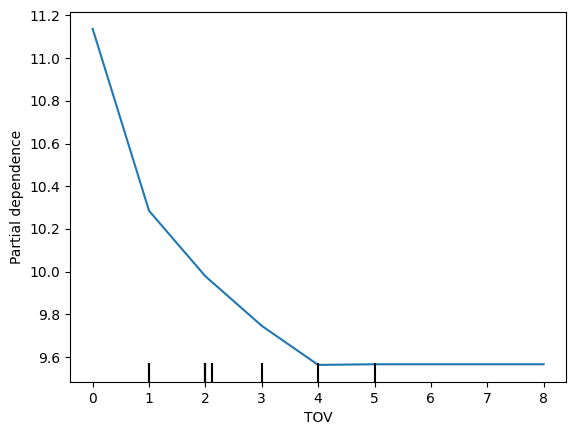

In [89]:
# plot the partial dependence plus-minus has on turnovers
PartialDependenceDisplay.from_estimator(rf, X, ['TOV'])

The graph shows a decreasing trend in plus-minus as turnovers increase, which makes sense because turnovers allow the other team to score, decreasing plus-minus. So based on this graph, we can conclude that turnovers should **negative relationship** to plus-minus, which is **not reflected in the importance**.


## Kernel Ridge Regressor

[Ridge Regression](https://www.ibm.com/think/topics/ridge-regression?utm_source=skills_network&utm_content=in_lab_content_link&utm_id=Lab-nba-shai-plus-minus-regressor-v1_1753133650), also known as **L2 Regression**, is a type of regularized linear regression that addresses [multicolinearity](https://www.ibm.com/think/topics/multicollinearity?utm_source=skills_network&utm_content=in_lab_content_link&utm_id=Lab-nba-shai-plus-minus-regressor-v1_1753133650) in input features by introducing a bias to the loss function. [Kernel Ridge Regression](https://scikit-learn.org/stable/modules/kernel_ridge.html) is a ridge regression model that applies the **kernel trick** to model non-linear relationships.


### $L_2$ Regularization

$L_2$ or Ridge Regularization is a regularization technique that applies a bias that counteracts the fit towards training data. By starting with a slightly worse fit to training data, the regression model can perform better general predictions in the long term. This reduces overfitting, but more importantly, addresses **multicolinearity** between features.

Let's take a look at a simple example with two input features and two data points:

<img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/P_krhbvpySFYmxxkhwoeNg/ols.png" width=50% alt="ols">

The red fitted line is a linear function in the form:

$$
size = weight * slope + y-intercept
$$

When **ordinary least squares (OLS)** determines the parameters for the values in this equations, it minimizes a loss function that represents the **sum of the squared residuals**. This is the sum of the squared distances of each training data point to the fitted line. We can see that the OLS minimization fits a red line that includes both training data points in the function.

In ridge regression, the loss function is given a bias or penalty that is represented by a value $ λ * m^2 $ (where $m$ = slope) which is **added** to the sum of the squared residuals.

$$
Loss = Σ(y_i - (m * x_i + b))^2  + (λ * m^2)
$$



The $λ$ is chosen from a grid of candidate values via **cross-validation** by calculating the penalized loss with λ and evaluating the **validation error** (find the λ that yields the lowest loss).

<img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/Puf4CJiSMKD42pKi1mdQpQ/ridge.png" width=50% alt="ridge">

The blue line represents the ridge regression line where even though the line doesn't fit the training data as well, it has a lower loss compared to the red line. This is because its slope is smaller and the added penalty gives the red line (larger slope) a **greater loss**. Both of these factors attribute to a **smaller overall loss** despite having greater residuals (distance to training data).

<img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/j0XiNG7i930GRMqmMcdM-w/ridge-points.png" width=50% alt="ridge_points">

Seeing both fits in practice with more data points, we conclude that the ridge regression (blue) line generalizes the data better than the pure OLS (red) line. This is the main benefit of ridge regression as it prevents overfitting on training data which allows the model to generalize and predict better results.


### Multicolinearity

Now let's discuss the main reason we're using ridge regression, **multicolinearity**. In our features, we have many **correlated** features like `PTS` and `FGM`. Regular OLS sees two features that behave similarily and doesn't know how to assign importance, therefore assigning one feature a large coefficient and the other a small coefficient based on tiny fluctuations in the data. **Ridge regression** adds a "rubber-band" (the penalty) that pulls colinear weights towards each other, splitting the **importances** that reflect similar contribution towards the target feature `PLUS_MINUS`.

Think of OLS as letting each feature’s “importance score” (its coefficient) roam free to match the data exactly. When two features always rise and fall together (are correlated), OLS can randomly give most of the credit to feature A and almost none to feature B. Ridge regression adds a “rubber‑band” around those importance scores: it says “I don’t want any score to get too big.” That rubber‑band is the penalty which tugs every weight towards zero without ever forcing them exactly to zero.

Let's take a look at the loss function in multivariate form:

$$
L(\boldsymbol\beta, b)
= \sum_{i=1}^n \bigl(y_i - (\mathbf{x}_i^\top \boldsymbol\beta + b)\bigr)^2
\;+\;\lambda \sum_{j=1}^p \beta_j^2
$$

Data fit term:
- The first term that computes the residual between the actual target feature values ($y$) of each training sample with the predicted target feature values ($\hat{y_i} = \mathbf{x}_i^\top \boldsymbol\beta + b$)
    - The model prediction ($\hat{y_i}$) is the dot product of all input features from the training sample ($x_i$) with a vector of feature coefficients ($\beta$) plus the y-intercept ($b$)
- This is the OLS loss function

$L_2$ penalty term:
- Since we are adding a penalty and our loss function aims to be minimized, smaller feature coefficients ($\beta_j$) will be chosen to minimize the loss function
- Furthermore, $\beta_j$ can never be pushed to zero because it's the squared $L_2$ norm, let's take a look at the derivative of the loss function with respect to the feature coefficient:
$$
\frac{\partial L}{\partial \beta_j}
= -2 \sum_{i=1}^n x_{ij}\,(y_i - \mathbf{x}_i^\top \boldsymbol\beta) \;+\; 2\lambda\,\beta_j
= 0
$$
    - At optimum we set the loss gradient to 0 (meaning it's at a minimum)
    - If we try to set $\beta_j = 0$, that would mean $-2 \sum_{i=1}^n x_{ij}\,(y_i - \mathbf{x}_i^\top \boldsymbol\beta) = 0$ which implies that the feature $x_j$ has zero correlation with each residual ($x_ij$ is $x_j$ in each training sample)
    - In conclusion, because the penalty’s gradient vanishes exactly at $β_j = 0$, the only way to satisfy the stationarity condition with $β_j = $0 is if the feature has zero correlation with the residuals
        - For any feature with non‑zero predictive power, $β_j$ can never equal zero under $L₂$ regularization.
- To explain the **balancing of multicolinearity**, consider two feature coefficients $\beta_a$ and $\beta_b$ that correspond to nearly identical features $x_a$ and $x_b$
    - The penalty in the loss function for these two feature coefficients would be $\lambda * (\beta_a^2 + \beta_b^2)$
    - To **minimize the penalty (loss)**, the weights must be distributed somewhat evenly $\beta_a \approx \beta_b$
    - This allows for feature importance to be **distributed evenly among colinear features**

Hopefully this explained Ridge ($L_2$) Regularization clearly, visit [here](https://www.ibm.com/think/topics/ridge-regression?utm_source=skills_network&utm_content=in_lab_content_link&utm_id=Lab-nba-shai-plus-minus-regressor-v1_1753897273) to learn more.


### Non-linear transformations

To allow for non-linear transformations, we can apply a function  
$\phi(\mathbf{x})$ that maps the input features to a higher-dimensional space:

$$
L(\boldsymbol\beta, b) 
= \sum_{i=1}^n \left( y_i - \left( \phi(\mathbf{x}_i)^\top \boldsymbol\beta + b \right) \right)^2 
+ \lambda \|\boldsymbol\beta\|^2
$$

As shown here with a single feature $ x $, we might define  $ \phi(x) = [x, x^2, x^3] $.


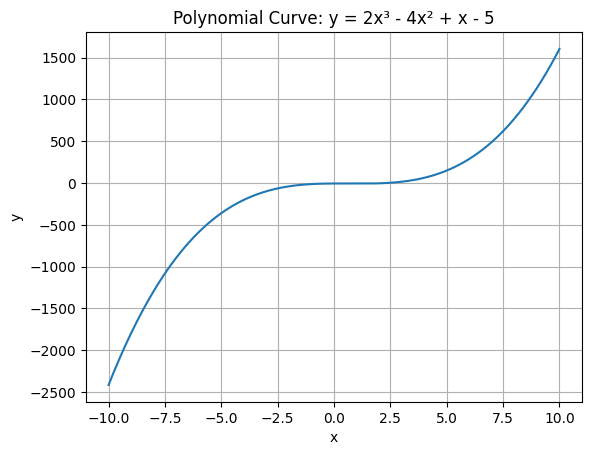

In [90]:
# generate x values
x = np.linspace(-10, 10, 400)

# define the polynomial
y_ = 2 * x**3 - 4 * x**2 + x - 5

# plot
plt.plot(x, y_)
plt.title("Polynomial Curve: y = 2x³ - 4x² + x - 5")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.show()

We can lift the input vector into a higher-dimensional feature space using a polynomial transformation.

For degree 2:
$$
\phi(\mathbf{x}) = (x_1, x_2, x_1^2, x_2^2, x_1 x_2)
$$

For degree 3:
$$
\phi(\mathbf{x}) = (x_1, x_2, x_1^2, x_2^2, x_1 x_2, x_1^3, x_2^3, x_1^2 x_2, x_1 x_2^2)
$$

$d$ is a hyperparameter. This grows very fast with both the input dimension and the polynomial degree.

### Kernel Trick

Rather than explicitly computing $\phi(\mathbf{x})$, we can use the **polynomial kernel function**:

$$
K(\mathbf{x}, \mathbf{x}') = (\mathbf{x} \cdot \mathbf{x}')^d
$$

Where  d is a hyperparameter that specifies the polynomial degree. You might wonder — how does this connect to ridge regression?





 For any  transformation  $\phi$  we define the kernal as :
$$
K(\mathbf{x},\mathbf{x}') = \phi(\mathbf{x})^\top \phi(\mathbf{x}')
$$

If we can compute $K(\mathbf{x},\mathbf{x}')$ without explicitly computing $\phi(\mathbf{x})$, we save computation while still benefiting from the higher-dimensional feature space.

Example (2D, degree 2):

$$
\phi(\mathbf{x}) = \big(x_1^2, \sqrt{2}x_1x_2, x_2^2\big)
$$
$$
\phi(\mathbf{x})^\top\phi(\mathbf{x}') = (x_1x_1' + x_2x_2')^2 = (\mathbf{x} \cdot \mathbf{x}')^2
$$


### Kernal Ridge regression
In standard Ridge regression in the feature space, the model is:
$$
\hat{y}(\mathbf{x}) = \phi(\mathbf{x})^\top \boldsymbol\beta+b
$$
where $\boldsymbol\beta$ is a vector of coefficients **in the high-dimensional space**.

However, when we solve for $\boldsymbol\beta$ (especially in ridge regression), it turns out that:
$$
\boldsymbol\beta = \sum_{j=1}^n \alpha_j \phi(\mathbf{x}_j)+b
$$
for some coefficients $\alpha_j$ (from the training data).  

Substituting back:
$$
\hat{y}(\mathbf{x}) = \phi(\mathbf{x}_i)^\top \boldsymbol\beta+b
= \sum_{i=1}^n \alpha_i \, \phi(\mathbf{x}_i)^\top \phi(\mathbf{x})+b
= \sum_{i=1}^n \alpha_j \, K(\mathbf{x}_i, \mathbf{x})+b
$$

**Key point:** We only need $K(\mathbf{x}_i, \mathbf{x})$ — the inner product in feature space — not $\phi(\mathbf{x}_i)$ itself.  
This is the **kernel trick** in regression: we can run polynomial (or other) regression in an extremely high-dimensional space without ever computing the high-dimensional vectors directly.




While ridge regression helps prevent overfitting and improves generalization, it does so by smoothing out the model, often at the cost of losing fine-grained detail. This makes it great for prediction, but less ideal for interpreting feature importance. To better capture the full complexity of the game data, we'll use the **kernel trick** to model all intricacies of the training data. This lets us fit complex, non‑linear patterns without ever explicitly constructing a huge feature vector. 

How the kernel trick works:
1. Linear models are too rigid
    - They fit straight lines or planes, can't model curved or complex patterns
2. Implicit feature mapping
    - Take your inputs 𝑥, and compute new features in higher dimensions (e.g., $x_i^2$) using kernel functions
    - In this new space, a linear model can fit more complex patterns
3. Kernel function
    - A kernel $k(x_i,x_j)$ computes the dot product in a rich feature space without ever building the high dimensional space (implicit)
    - In kernelized models like \textbf{Kernel Ridge Regression} and \textbf{Support Vector Machines (SVMs)}, the prediction function becomes:
$$


Using the **polynomial kernel function**, we apply Kernel Ridge Regression to fit noisy samples from the previous cubic polynomial example. We'll plot the predicted curve alongside every fifth noisy training point.


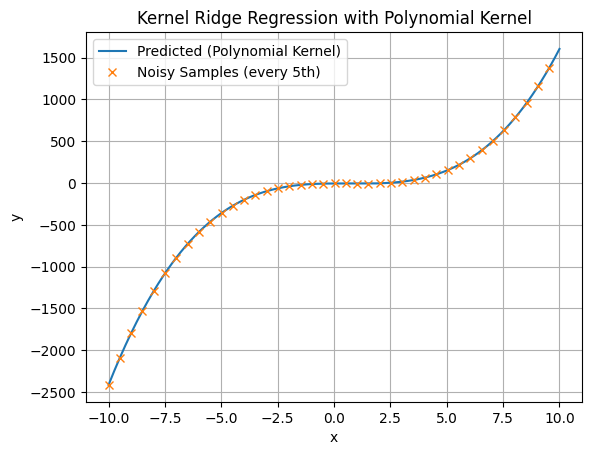

In [91]:
# add noise to the data
y_noisy = y_ + np.random.normal(loc=0.0, scale=0.2, size=y_.shape)

# Kernel Ridge Regression with polynomial kernel
model = KernelRidge(kernel='polynomial', degree=3, coef0=1, alpha=1.0)
model.fit(x.reshape(-1, 1), y_noisy.reshape(-1, 1))

# predict
y_pred = model.predict(x.reshape(-1, 1))

# plot predictions and every 5th noisy sample
plt.plot(x, y_pred, label='Predicted (Polynomial Kernel)')
plt.plot(x[::10], y_noisy[::10], 'x', label='Noisy Samples (every 5th)')
plt.title("Kernel Ridge Regression with Polynomial Kernel")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.legend()
plt.show()

Here's another example of a common kernel function.

- **Radial Basis Function (RBF) kernel**
   $$
     k(x_i,x_j)=\exp\bigl(-\gamma\|x_i-x_j\|^2\bigr).
   $$
   - Detects smooth similarity
   - It assumes that points closer together have more exponentially higher similarly and computes distances between points
   - In RBF, you can think of $\gamma$ as the kernel's scope or width between data points. Mathematically the gamma is:

    $$
    \gamma = \frac{1}{2\sigma^2} \quad \Leftrightarrow \quad \sigma = \sqrt{\frac{1}{2\gamma}}
    $$

   - Larger $\gamma$ -> smaller $\sigma$ -> **narrow Gaussian bump** -> only very close points are similar
   - Smaller $\gamma$ -> larger $\sigma$ -> **wider Gaussian bump** -> more points are considered similar
   - Each data point has a Gaussian distribution of influence from neaby points
       - Wider bumps (distributions) mean more points have influence on the data point
       - Narrow bumps mean less points have influence on the data point
For the RBF kernel, we can’t even explicitly compute $\phi(\mathbf{x})$ — the feature space is infinite-dimensional!


Here's a simple and general visualization of how the kernel trick works. Imagine all our data points are in 1D and can be represented as a colored point on a number line where the color represents the target features (red/blue).

<img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/L7GJGROTgS9PqdkUaE9wqQ/line.png" width=100% alt="line">

Clearly the points are not linearly separable on a 1D number line. You cannot draw a single linear line that defines the two different categories.

This is where mapping to higher dimensions comes in handy. **Feature maps** are functions that map data points to a higher dimension. **Kernel functions** use feature maps to transform features into higher-dimensional spaces. In our simple example, we use the feature map $y = x^2$ to map data points from 1D to 2D.

<img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/TCsSWRfdORcGumnZYr2wlA/graph.png" width=70% alt="graph">

Now that the data is mapped to a higher dimension, it's easier to distinguish patterns that were hard to capture in the original space. We can easily find a linear function (straight line) to separate the classes in our example.

By mapping features to a higher-dimensional space (using the kernel trick), we give the model the flexibility to:

- Accurately represent each game situation by capturing subtle feature interactions in the data
- Assign meaningful importance to player actions
- Capture complex, nonlinear effects


### Hyperparameters (Ridge)

First we'll create our Grid Search Cross Validator using the `KernelRidge` estimator. We'll configure it to have the following hyperparameters:

- `alpha` (`λ`): Controls the regularization penalty, with larger values shrinking weights more to prevent over‑fitting
- `kernel`: Specifies the similarity (kernel) function that defines the feature space in which you fit a linear model
- `gamma`: A scaling factor applied to the kernel’s input where larger $γ$ makes the kernel more sensitive to small differences and smaller $γ$ yields smoother, more global similarity.(only used by `polynomial` and `rbf` kernel functions)
- `degree`: The exponent of the dot‑product that controls how many high‑order feature interactions to include. (only used by `polynomial` kernel function)
- `coef0`: An added constant term that balances the influence of higher‑order versus lower‑order terms (only used by `polynomial` kernel function)


In [92]:
# build the parameter grid
param_grid_kr = {
    'alpha':   [1e-3, 1e-2, 1e-1, 1, 10, 100], # L2 regularization penalty
    'kernel':  ['linear', 'polynomial', 'rbf'], # kernel function for calculating similarity
    'gamma':   [1e-3, 1e-2, 1e-1], # scaling factor for polynomial and rbf
    'degree':  [2, 3, 4], # exponent of higher order terms in polynomial
    'coef0':   [0.0, 1.0] # balancing term in polynomial
}

### Grid Search Cross-Validation (Ridge)

Then we'll instantiate a `GridSearchCV` and pass in the following configurations:
- `estimator`: Kernel Ridge Regressor instance
- `param_grid`: Our grid of parameters that will be cross validated
- `cv`: Number of **k-folds**, dividing the dataset into k-1 training sets and 1 validation set
- `scoring`: $R^2$ score for cross validation
- `n_jobs`: Number of CPU cores used for hyperparameter search (-1 means all possible cores)


In [93]:
# setup the grid search
grid_search_kr = GridSearchCV(
    estimator=KernelRidge(), # kernel ridge regressor
    param_grid=param_grid_kr, # parameters
    cv=4, # k-folds, number of splits in data, k-1 become training data, the last becomes testing data
    scoring='r2', # use r2 scoring to find best parameters
    n_jobs=-1 # use all available cpu cores
)

Like before we'll fit the grid search to our training data subset. We'll print the best parameters and create a reference that points to the `best_estimator_` (kernel ridge regressor) field of the grid search. This best estimator is configured with the best parameters.


In [94]:
# fit to training data
grid_search_kr.fit(X_train, y_train)

# best parameters
print("Best Parameters:", grid_search_kr.best_params_)

# model with the best parameters
kr = grid_search_kr.best_estimator_

Best Parameters: {'alpha': 1, 'coef0': 1.0, 'degree': 2, 'gamma': 0.001, 'kernel': 'polynomial'}


### Scoring (Ridge)

Like the Random Forest Regressor, we'll use $R^2$ score to determine the accuracy and fit of the regressor. Unlike the random forest regressor with bootstrapping, kernel ridge regression has no "randomness" to it. Therefore, the $R^2$ score will be the same when you fit a model with consistent hyperparameters with the same training datasets.

Run the following code cell to see the Kernel Ridge Regression score.


In [95]:
# get the r2 score based on test data
r2 = kr.score(X_test, y_test)
print(f"R² score: {r2:.3f}")

R² score: 0.129


### Importances (Ridge)

Unlike the random forest regressor, kernel ridge doesn't use weights that directly correlate to importances hence the model has no property to get importances and we have to calculate them ourselves. Luckily, `scikit-learn` has a function `permutation_importance` that measures changes in target feature as you randomly shuffle one feature at a time. These measurements can be taken as **permutation importances**.


In [96]:
# get the permutation importances of each feature X toward target feature y
result = permutation_importance(
    kr, # estimator
    X, # all features
    y, # all target features
    n_repeats=10, # number of times a feature is shuffled and returns a sample of feature importance
    scoring='r2' # scoring method to determine how well the target feature is determined
)

# get the average of all 10 importances for each feature
importances = result.importances_mean

# create the series with labels from our features
kr_imp = pd.Series(importances, index=X.columns)
kr_imp_sorted = kr_imp.sort_values(ascending=False)

# print the top and bottom importances
print(f"Top importances: \n{kr_imp_sorted.head(5)}\n") 
print(f"Bottom importances: \n{kr_imp_sorted.tail(5)}")

Top importances: 
MIN    0.187021
PTS    0.164112
TOV    0.085823
AST    0.083096
FGM    0.041470
dtype: float64

Bottom importances: 
BLK           -0.000007
AST_per_min   -0.000012
opp_MIL       -0.000021
AST_TOV       -0.000030
opp_ORL       -0.000043
dtype: float64


Again, these importances are unsigned and only represent **magnitudes** of affect on plus-minus. Let's take a look at `TOV` again to find its directional relationship to the target feature.


In [97]:
f"Turnover Importance Magnitude: {kr_imp['TOV']}"

'Turnover Importance Magnitude: 0.08582311260207934'

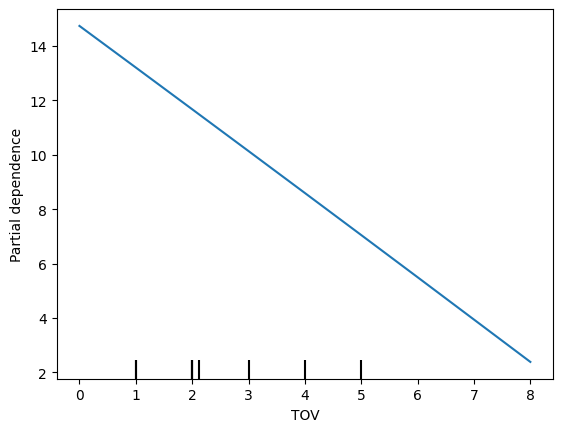

In [98]:
PartialDependenceDisplay.from_estimator(kr, X, ['TOV'])

From the graph we can see the same decreasing trend that the random forest regressor showed. Note that the curve is smoother here because of the kernel function that uses **dimensionality splits** to classify data into more specificied groups. In random forest regression, the points are classified into broader, more generalized groups that result in **piecewise** function (jagged) partial dependence plots.


Now that we have linear correlations and importances from two different regressors, we can derive an **attribution score** from the ranked average of each feature (game stat).


## Deriving Attribution

We have three different metrics that reflect the **attribution of each stat** towards plus-minus (to some extent):
- **Pearson Correlation:** linear, bivariate, captures simple linear relationships
- **Random Forest MDI Importances:** multivariate, tree‑based magnitude, captures complex non-linear relationships
- **Kernel Ridge Permutation Importances:** multivariate, kernel‑based magnitude, captures non-linear relationships and handles multicolinearity

Each of these measurements can be seen as impact values of a stat towards performance, capturing different nuances within the data and providing complementary insights.


In [99]:
# create our dataframe of metrics that each reflect attribution of a feature towards plus-minus
metrics_df = pd.DataFrame({
    'corr' : abs_corrs,
    'rf'   : rf_imp,
    'kr'   : kr_imp
})

Using these three metrics as loose indicators of plus-minus attribution, we can use **Borda-count (rank aggregation)** to find the features with the largest impact on the plus-minus score.
- A voting method that counts the ranking of different features across different metrics
- Each feature has a different `corr`, `kr_imp`, and `rf_imp`, they are each ranked and the rankings are added up
- The most significant features have the lowest **borda counts**


In [100]:
# create a dataframe for ranking
rank_df = pd.DataFrame()

# rank the correlations
rank_df['rank_corr'] = metrics_df['corr'].rank(ascending=False)
# rank the random forest importance
rank_df['rank_rf'] = metrics_df['rf'].rank(ascending=False)
# rank the kernel ridge importance
rank_df['rank_kr'] = metrics_df['kr'].rank(ascending=False)
# get the borda counts of each metric (sum of rankings)
rank_df['borda'] = rank_df[['rank_corr', 'rank_rf','rank_kr']].sum(axis=1)
# sort the dataframe by borda count
rank_df = rank_df.sort_values('borda')

# print the 10 lowest borda counts, these have the greatest attribution towards plus-minus
rank_df.head(10)

,rank_corr,rank_rf,rank_kr,borda
PTS,6.0,7.0,2.0,15.0
PTS_per_min,1.0,2.0,18.0,21.0
FGM,5.0,12.0,5.0,22.0
is_home,4.0,11.0,8.0,23.0
TOV,2.0,18.0,3.0,23.0
MIN,23.0,6.0,1.0,30.0
AST,15.0,22.0,4.0,41.0
FG_PCT,7.0,1.0,34.0,42.0
STL,11.0,28.0,6.0,45.0
TOV_per_min,3.0,4.0,39.0,46.0


Based on the Borda rank aggregation, we can clearly see where multivariate regression differs from linear correlation. Let's isolate `MIN` (minutes played), analyze it, and draw meaningful conclusions.

#### Rank Discrepancy

At face value, it's difficult to determine whether minutes played has a consistent relationship with `PLUS_MINUS`. Intuitively, playing more minutes doesn't necessarily guarantee better on-court impact—what matters is what you do during those minutes.

However, the Borda rankings reveal something interesting:

- Correlation rank: 23 (very poor)
- Random Forest rank: 3 (excellent)
- Kernel Ridge rank: 2 (excellent)

**Remember these rankings are from my iteration and will be different for you**

The multivariate regressors ranked MIN much higher than the bivariate correlation. What non-linear relationship did the regressors identify that correlation missed?

Let's examine the **Partial Dependence Plot** using the **Random Forest Regressor** to understand the **marginal** effect of `MIN` on the target feature `PLUS_MINUS` using the partial dependence formula:

$$
PD_j(x_j) = \frac{1}{n} \sum_{i=1}^{n} f(x_j, x_{-j}^{(i)})
$$

- $PD_j(x_j)$ is the partial dependence value
- $\frac{1}{n} \sum_{i=1}^{n}$ takes the summed average of each datapoint
- $f(x_j, x_{-j}^{(i)})$ is the trained regression model that predicts the target feature using a modified $x_j$ feature while all other features remain the same

The algorithm:
- Picks a value for the feature you're interested in (e.g., `MIN` = 13)
- For each data point in your dataset, replaces that feature with your chosen value
- Keeps all other features at their original values
- Runs the model on each modified data point
- Averages all the predictions
- Repeats for different values of your feature
- Plots the results

This gives you the **isolated** effect of that one feature on the model's predictions.


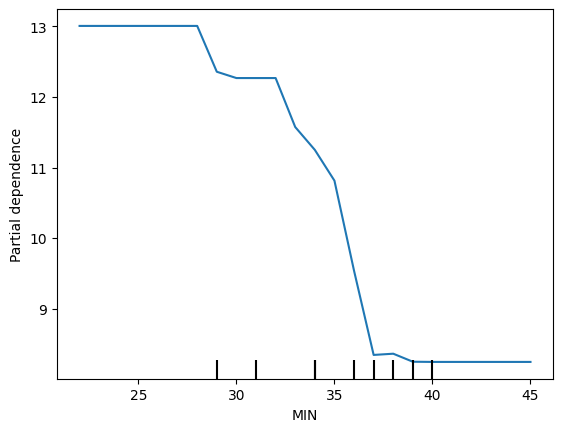

In [101]:
PartialDependenceDisplay.from_estimator(rf, X, ['MIN'])

The graph is likely curved and jagged in many areas, it's non-linear. Revealing key insights:
- The `MIN` feature is significantly correlated with other features
- Non-linear relationships are hard to capture with bivariate correlation, but not with multivariate regressors
- There may be threshold effects: sweet spots where certain amount of minutes helps

Let's explore this further and find the correlation of `MIN` to other features. As a baseline, we'll use something relatively isolated like `TOV` to compare the correlations of `MIN` with. Let's manipulate the stats matrix to find correlations.


In [102]:
min_correlations = stats_df.corr()['MIN'].sort_values(ascending=False)
tov_correlations = stats_df.corr()['TOV'].sort_values(ascending=False)

print("Turnover correlations")
print(tov_correlations.head(5))

print("Minutes correlations")
print(min_correlations.head(5))

Turnover correlations
TOV            1.000000
TOV_per_min    0.974577
opp_SAC        0.207980
opp_IND        0.158182
opp_BOS        0.100812
Name: TOV, dtype: float64
Minutes correlations
MIN    1.000000
FGA    0.586732
PF     0.458376
PTS    0.452194
FTA    0.416551
Name: MIN, dtype: float64


Like before, the first correlation should be the feature itself with a value of 1 meaning it has a perfect linear relationship to itself. Taking a look down the list we observe that `TOV` is highly correlated to `TOV_per_min` (makes sense), and not so highly correlated with anything else. Unlike `TOV`, `MIN` shows strong correlations with multiple statistics. These relationships are impossible to capture with Pearson correlations as they only see the bivariate relationship between `MIN` and `PLUS_MINUS`. It may miss the indirect pathway of increased minutes → more opportunities → better stats → higher plus-minus.

The bottom line is that `MIN` ranks poorly in correlation because it doesn't directly cause plus-minus improvement, but it enables the conditions (more shot attempts, more scoring opportunities) that **may** improve plus-minus significantly. The multivariate regressors detect this indirect but crucial relationship, while bivariate correlation misses it entirely.

This perfectly illustrates why **multivariate analysis** is superior for understanding complex, interconnected systems like basketball performance.


Knowing that feature importances derived from regressors are superior, we'll drop the correlation ranks from our rankings Dataframe and recalculate the Borda count to reflect that.


In [103]:
# get the borda counts of each regressor (multivariate analysis only)
rank_df['borda'] = rank_df[['rank_rf','rank_kr']].sum(axis=1)

# drop the correlation rank
rank_df = rank_df.drop(columns=['rank_corr'])

# sort by ascending borda
rank_df = rank_df.sort_values('borda')

# print the 10 lowest borda counts, these have the greatest attribution towards plus-minus
rank_df.head(10)

,rank_rf,rank_kr,borda
MIN,6.0,1.0,7.0
PTS,7.0,2.0,9.0
FGM,12.0,5.0,17.0
is_home,11.0,8.0,19.0
PTS_per_min,2.0,18.0,20.0
TOV,18.0,3.0,21.0
AST,22.0,4.0,26.0
FTM,15.0,14.0,29.0
FTA,16.0,13.0,29.0
FG3A,20.0,12.0,32.0


## Conclusion

Let's take our data, plot it out, and draw some conclusions.


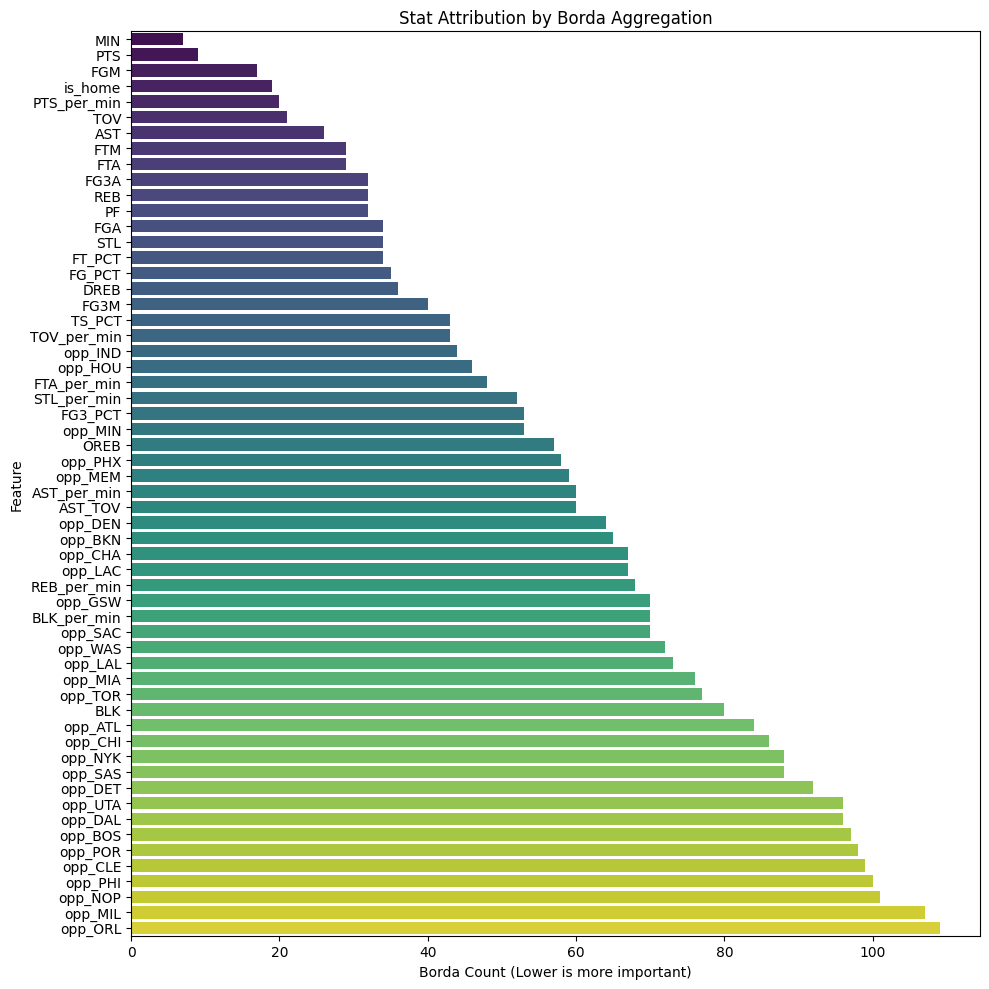

In [104]:
# configure figure size
plt.figure(figsize=(10, 10))
# give color gradient to the bar graph
sns.barplot(x='borda', y=rank_df.index, data=rank_df, hue=rank_df.index, palette='viridis')
# graph labels
plt.xlabel("Borda Count (Lower is more important)")
plt.ylabel("Feature")
plt.title("Stat Attribution by Borda Aggregation")
# padding between subplots (features)
plt.tight_layout()

plt.show()

From the graph, we observe that the top-ranked features—such as `PTS`, `TOV`, `AST_TOV`, and `MIN` consistently rank high across all metrics, highlighting core aspects of Shai’s on-court impact:

- **Scoring volume and efficiency** (`PTS`, `FGM`, `PTS_per_min`) is the most dominant contributor
- Turnovers (`TOV`) show up as an important **negative factor stat** that reduces plus-minus
- Minutes played (`MIN`) reinforces the idea that Shai’s **time on court** heavily influences team performance
- **Possession efficiency** (`AST_TOV`) shows that Shai is a productive player when the ball is in his hands, oftentimes converting possessions into points rather than losing the ball

In contrast, features with **high** Borda scores (lower importance) include many opponent-specific dummy variables, derived rate stats, and noise-prone metrics such as `BLK_per_min` and individual opponent matchups (`opp_PHI`, `opp_BOS`, etc.). These (engineered) features typically suffer from **data sparsity, high variance, or triviality**, making their contributions to plus-minus statistically **inconclusive** or contextually **uninformative**.

Overall, the top ranked statistics from this analysis offer a grounded view of what drives Shai's on-court value, and they align well with **intuitive basketball principles**: high scoring efficiency, ball control, and consistent floor presence.


## Exercises


### Exercise 1: Data Preprocessing and Feature Engineering

1. Parse and clean training data
2. Engineer features to target hidden feature relationships


In [105]:
teams_df2 = pd.read_csv('./NBA-TEAMS.csv')
games_df2 = pd.read_csv('./NBA-GAMES.csv')
player_games_df2 = pd.read_csv('./NBA-PLAYER-GAMES.csv')
players_df2 = pd.read_csv('./NBA-PLAYERS.csv')

In [106]:
players_df2

,id,full_name,first_name,last_name,is_active
0,76001,Alaa Abdelnaby,Alaa,Abdelnaby,False
1,76002,Zaid Abdul-Aziz,Zaid,Abdul-Aziz,False
2,76003,Kareem Abdul-Jabbar,Kareem,Abdul-Jabbar,False
3,51,Mahmoud Abdul-Rauf,Mahmoud,Abdul-Rauf,False
4,1505,Tariq Abdul-Wahad,Tariq,Abdul-Wahad,False
...,...,...,...,...,...
5019,1627826,Ivica Zubac,Ivica,Zubac,True
5020,78650,Matt Zunic,Matt,Zunic,False
5021,1641783,Tristan da Silva,Tristan,da Silva,True
5022,1628427,Vlatko Čančar,Vlatko,Čančar,True


In [111]:
# Let's check for players with names similar to "Luka"
print("Players with names containing 'Luka':")
print(players_df[players_df['full_name'].str.contains('Luka', case=False, na=False)])

# Alternative approach - let's see if we can find him by last name
print("\nPlayers with names containing 'Doncic':")
print(players_df[players_df['full_name'].str.contains('Doncic', case=False, na=False)])

Players with names containing 'Luka':
           id     full_name first_name last_name  is_active
1134  1629029   Luka Dončić       Luka    Dončić       True
1524  1630568    Luka Garza       Luka     Garza       True
3898  1629677  Luka Samanic       Luka   Samanic      False

Players with names containing 'Doncic':
Empty DataFrame
Columns: [id, full_name, first_name, last_name, is_active]
Index: []


In [112]:
# Enter a player's name with the correct spelling from the database
player_name = "Luka Dončić"

# Get player ID from players_df
player_id = players_df[players_df['full_name'] == player_name]['id'].iloc[0]

# Build dataframe for stats of each game using player_games_df
games_df = player_games_df[player_games_df['Player_ID'] == player_id]

# Create numeric-only dataframe
stats_df = games_df.select_dtypes(include=['int64', 'float64'])

# Drop numeric metadata features
stats_df = stats_df.drop(columns=[
    'SEASON_ID',
    'Player_ID',
    'Game_ID',
    'VIDEO_AVAILABLE'
])

# Engineer assist-to-turnover ratio
stats_df["AST_TOV"] = stats_df['AST'] / (stats_df['TOV'] + 0.1)

# Engineer defensive rating
stats_df["DEF_RATE"] = (stats_df['STL'] + stats_df['BLK']) / stats_df['MIN']

# Print the stats dataframe
stats_df

,MIN,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,REB,AST,STL,BLK,TOV,PF,PTS,PLUS_MINUS,AST_TOV,DEF_RATE
163,40,7,18,0.389,2,8,0.250,12,15,0.800,0,7,7,9,1,0,2,4,28,-5,4.285714,0.025000
382,40,7,18,0.389,2,8,0.250,12,15,0.800,0,7,7,9,1,0,2,4,28,-5,4.285714,0.025000
600,40,7,18,0.389,2,8,0.250,12,15,0.800,0,7,7,9,1,0,2,4,28,-5,4.285714,0.025000
843,40,7,18,0.389,2,8,0.250,12,15,0.800,0,7,7,9,1,0,2,4,28,-5,4.285714,0.025000
1062,40,7,18,0.389,2,8,0.250,12,15,0.800,0,7,7,9,1,0,2,4,28,-5,4.285714,0.025000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16282,38,12,25,0.480,3,7,0.429,2,4,0.500,0,5,5,2,1,0,1,5,29,-2,1.818182,0.026316
16283,40,10,27,0.370,1,8,0.125,3,4,0.750,1,7,8,8,1,0,3,2,24,3,2.580645,0.025000
16284,33,5,22,0.227,1,9,0.111,4,6,0.667,0,9,9,8,2,1,2,5,15,5,3.809524,0.090909
16285,39,12,25,0.480,5,13,0.385,11,12,0.917,1,9,10,4,0,1,2,4,40,-12,1.904762,0.025641


<details>
    <summary>Click here for Solution</summary>

```python
# Enter an NBA player's name to search for the player's stats
player_name = "kevin durant"
# get the id of the first player in the search
player_id = players_df[players_df['full_name'].str.contains(player_name, case=False, na=False)].id.values[0]

# build a dataframe for stats of each game
games_df = (
    player_games_df
    .loc[player_games_df['Player_ID'] == player_id]
    .sort_values('GAME_DATE', ascending=True)
    .reset_index(drop=True)
)

# create a new dataframe with only numeric features
stats_df = games_df.select_dtypes(include='number').copy()

# drop numeric metadata features
stats_df = stats_df.drop(columns=[
   "SEASON_ID", "Player_ID", "Game_ID", "VIDEO_AVAILABLE"
])

# engineer an assist turnover feature
stats_df["AST_TOV"] = stats_df["AST"] / stats_df["TOV"].replace(0, 1)

# engineer a defensive rating feature
stats_df["DEF_RATE"] = stats_df["BLK"] + stats_df["STL"]

# print the stats dataframe
stats_df
```

</details>


### Exercise 2: Model Training and Scoring (RF and KRR)

1. Define training data (features and target feature)
2. Create a train-test split for cross validation
3. Fit a Random Forest and Kernel Ridge Regressor on the data
4. Derive $R^2$ scores from each model


In [113]:
# Define feature columns - we'll use all numeric stats except PLUS_MINUS (target)
feature_cols = [
    'MIN', 'FGM', 'FGA', 'FG_PCT', 
    'FG3M', 'FG3A', 'FG3_PCT',
    'FTM', 'FTA', 'FT_PCT',
    'OREB', 'DREB', 'REB',
    'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS',
    'AST_TOV', 'DEF_RATE'  # Including our engineered features
]
X = stats_df[feature_cols]
y = stats_df['PLUS_MINUS']

# Split the data 80/20 (train/test) with random_state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Build and fit the random forest regressor
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=5,
    min_samples_leaf=3,
    max_features='sqrt',
)
rf.fit(X_train, y_train)  # Fit the model on training data

# Build and fit the kernel ridge regressor
kr = KernelRidge(
    alpha=0.1,
    kernel='rbf',
    gamma=0.1
)
kr.fit(X_train, y_train)  # Fit the model on training data

# Score each model using R² (coefficient of determination)
rf_r2 = rf.score(X_test, y_test)  # Score RF on test data
kr_r2 = kr.score(X_test, y_test)  # Score KRR on test data

# Print the scores
rf_r2, kr_r2

(0.4657791752823831, -0.008503162022137856)

<details>
    <summary>Click here for Solution</summary>

```python
# separate features and target
feature_cols = clean_df.drop(columns='PLUS_MINUS').columns
X = clean_df[feature_cols]
y = clean_df['PLUS_MINUS']

# use the train_test_split function to split the data 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# build the random forest regressor with the configurations
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=5,
    min_samples_leaf=3,
    max_features='sqrt',
)

# fit the model on our data
rf.fit(X_train, y_train)

# build the kernel ridge regressor with configurations
kr = KernelRidge(
    alpha=0.1, # regularization (penalty) strength
    kernel='rbf', # kernel function that computes in higher dimensions
    gamma=0.1 # kernel width  
)

# fit the model to our data
kr.fit(X_train, y_train)

# score each model
rf_r2 = rf.score(X_test, y_test)
kr_r2 = kr.score(X_test, y_test)

# print the scores
rf_r2, kr_r2
```

</details>


### Exercise 3: Calculate Importances and Draw Conclusions

1. Get the feature importances from the Random Forest Regressor
2. Use `permutation_importance` to find importances from the Kernel Ridge Regressor
3. Use borda count to determine the most important parts of your NBA player's game


In [114]:
# Get Random Forest feature importances
importances = rf.feature_importances_

# Create a series matching importances with feature labels
rf_imp = pd.Series(importances, index=feature_cols)

# Get permutation importances for Kernel Ridge
result = permutation_importance(
    kr,          # the model
    X_test,      # features
    y_test,      # target feature
    n_repeats=10,
    scoring='r2'
)

# Get the mean importances from permutation results
importances = result.importances_mean

# Create a series with feature labels
kr_imp = pd.Series(importances, index=feature_cols)

# Create metrics dataframe (already provided)
metrics_df = pd.DataFrame({
    'rf'   : rf_imp,
    'kr'   : kr_imp
})

# Create ranking dataframe
rank_df = pd.DataFrame()

# Rank the importances (ascending=False means higher importance gets lower rank number)
rank_df['rank_rf'] = metrics_df['rf'].rank(ascending=False)
rank_df['rank_kr'] = metrics_df['kr'].rank(ascending=False)

# Calculate Borda count (sum of rankings)
rank_df['borda'] = rank_df['rank_rf'] + rank_df['rank_kr']

# Sort by Borda count (ascending because lower Borda count means more important)
rank_df = rank_df.sort_values('borda', ascending=True)

# Print top 10 most important features (already provided)
rank_df.head(10)

,rank_rf,rank_kr,borda
MIN,5.0,3.0,8.0
AST_TOV,2.0,7.0,9.0
FTM,10.0,2.0,12.0
FGA,7.0,6.0,13.0
PTS,11.0,4.0,15.0
FTA,14.0,1.0,15.0
STL,3.0,14.0,17.0
DEF_RATE,1.0,18.0,19.0
TOV,12.0,8.0,20.0
DREB,9.0,12.0,21.0


<details>
    <summary>Click here for Solution</summary>

```python
# random forest regressor importances
importances = rf.feature_importances_

# match the importances with feature labels in a series
rf_imp = pd.Series(importances, index=X.columns)

# get the permutation importances of each feature X toward target feature y
result = permutation_importance(
    kr, # model
    X, # features
    y, # target feature
    n_repeats=10, # number of times a feature is shuffled and returns a sample of feature importance
    scoring='r2' # scoring method to determine how well the target feature is determined
)

# get the average of all n_repeats importances for each feature
importances = result.importances_mean

# create the series with labels from our features
kr_imp = pd.Series(importances, index=X.columns)

# create our dataframe of metrics that each reflect attribution of a feature towards plus-minus
metrics_df = pd.DataFrame({
    'rf'   : rf_imp,
    'kr'   : kr_imp
})

# create a dataframe for ranking
rank_df = pd.DataFrame()

# rank the random forest importance
rank_df['rank_rf'] = metrics_df['rf'].rank(ascending=False)
# rank the kernel ridge importance
rank_df['rank_kr'] = metrics_df['kr'].rank(ascending=False)
# get the borda counts of each metric (sum of rankings)
rank_df['borda'] = rank_df[['rank_rf','rank_kr']].sum(axis=1)
# sort the dataframe by borda count
rank_df = rank_df.sort_values('borda')

# print the 10 lowest borda counts, these have the greatest attribution towards plus-minus
rank_df.head(10)
```

</details>


## Conclusion

In this notebook, we explored the statistical underpinnings of **plus-minus** for an NBA player by combining classical correlation with model-based attribution techniques. Using a dataset of per-game stats, we trained two regression models, **Random Forest** and **Kernel Ridge**, to predict the player's impact on team performance. We then extracted feature importances from both models alongside **Pearson correlations**, and synthesized the results using **Borda rank aggregation**.

## Next Steps

To build on this analysis or pursue heuristic extensions, consider the following next steps:

1. **Model Improvements**
   - Tune hyperparameters for `KernelRidge` (`alpha`, `gamma`) and `RandomForest` (`max_depth`, `n_estimators`) using grid search or randomized search.
   - Try other interpretable regressors like **Lasso**, **ElasticNet**, or **Gradient Boosting Machines**.
   - Evaluate models using metrics beyond R² — e.g. **MAE**, **RMSE**, or residual diagnostics.

2. **Feature Engineering**
   - Incorporate contextual features like **opponent strength**, **game location**, or **rest days**.
   - Encode time-dependent features: **rolling averages**, **game streaks**, or **injury status**.
   - Include synergy features: player + teammate combinations, lineup effects, etc.

3. **Explainability**
   - Use **SHAP** or **LIME** (when possible) to get localized explanations for individual games.
   - Build **partial dependence plots (PDPs)** to visualize how specific features influence predictions non-linearly.

4. **Generalization**
   - Extend the analysis to multiple players or entire teams to compare attribution across roles and positions.
   - Deploy the notebook as an interactive dashboard using **Streamlit** or **Voila**.

5. **Domain Integration**
   - Align your statistical findings with **game film**, **coaching decisions**, or **scouting reports** for richer insights.
   - Collaborate with basketball analysts or use insights for **fantasy sports**, **sports betting**, or **front-office analytics**.


## Authors


[Joshua Zhou](https://author.skills.network/instructors/joshua_zhou) | Data Scientist Intern @ IBM


Copyright © 2025 IBM Corporation. All rights reserved.
